In [5]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer



# One-time downloads (run once)
nltk.download('stopwords')

# -------------------- Step 1: Load the Excel File --------------------
df=pd.read_csv("sentiment_data.csv", comment='#')  # ignore lines starting with '#', let delimiter default to comma

# Check the data
print(df.shape)
print(df.head())

(50, 5)
   id                                               text sentiment  \
0   1  Absolutely love this product! It exceeded all ...  positive   
1   2  The service was okay, nothing special. Deliver...   neutral   
2   3  Terrible experience! The product arrived damag...  negative   
3   4  This is the best purchase I've made this year!...  positive   
4   5  Received the package today. It looks decent bu...   neutral   

              source        date  
0     Product Review  2026-01-15  
1  Customer Feedback  2026-01-16  
2     Product Review  2026-01-17  
3       Social Media  2026-01-18  
4       Social Media  2026-01-19  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
df.columns

Index(['id', 'text', 'sentiment', 'source', 'date'], dtype='object')

In [7]:
df['sentiment'].value_counts()

,count
sentiment,
positive,17
neutral,17
negative,16


In [8]:
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [9]:
# Drop rows with nulls in the columns that matter
df.dropna(subset=['text', 'sentiment'], inplace=True)

# Drop duplicate reviews
df.drop_duplicates(subset=['text'], inplace=True)

# Check unique sentiment labels (confirm exact spelling/casing)
print(df['sentiment'].unique())

['positive' 'neutral' 'negative']


In [10]:
df.shape

(50, 5)

In [11]:
df['sentiment_encoded'] = df['sentiment'].str.lower().str.strip().map({
    'negative': 0,
    'neutral': 1,
    'positive': 2
})

In [12]:
df['sentiment_encoded'].isnull().sum()

np.int64(0)

In [16]:
df['sentiment_encoded'].head(5)

,sentiment_encoded
0,2
1,1
2,0
3,2
4,1


In [20]:
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet # Import wordnet

nltk.download('averaged_perceptron_tagger_eng') # Ensure this specific tagger is downloaded

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def clean_and_lemmatize(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [w for w in words if w not in stop_words]

    tagged = pos_tag(words)
    words = [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in tagged]

    return ' '.join(words)

df['cleaned_text'] = df['text'].apply(clean_and_lemmatize)

# Save cleaned data (keeping source/date in case you want them later)
df.to_csv('cleaned_sentiments.csv', index=False)
print("Saved cleaned_sentiments.csv")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Saved cleaned_sentiments.csv


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_text'])
y = df['sentiment_encoded']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=300),
    'SVM': SVC(kernel='linear')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    results[name] = {'model': model, 'accuracy': acc, 'f1': f1}
    print(f"{name}: Accuracy = {acc:.4f}, F1 (weighted) = {f1:.4f}")

Naive Bayes: Accuracy = 1.0000, F1 (weighted) = 1.0000
Logistic Regression: Accuracy = 0.9000, F1 (weighted) = 0.9000
SVM: Accuracy = 0.9000, F1 (weighted) = 0.9000


In [24]:
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = results[best_model_name]['model']
print(f"Best Model: {best_model_name}")

y_pred = best_model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['negative', 'neutral', 'positive']))

Best Model: Naive Bayes

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         3
     neutral       1.00      1.00      1.00         4
    positive       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



sentiment          negative  neutral  positive
source                                        
Customer Feedback         4        5         5
Product Review            7        5         7
Social Media              5        7         5


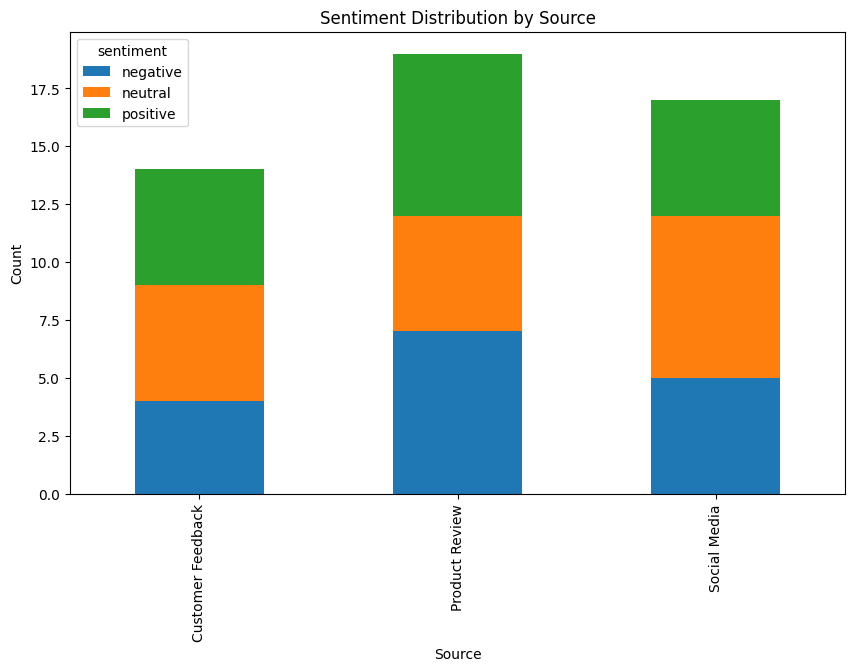

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sentiment distribution across platforms
sentiment_by_source = df.groupby(['source', 'sentiment']).size().unstack(fill_value=0)
print(sentiment_by_source)

sentiment_by_source.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Sentiment Distribution by Source')
plt.xlabel('Source')
plt.ylabel('Count')
plt.show()

In [30]:
def predict_sentiment(text):
    # Step 1: Clean & lemmatize the input the same way as training data
    cleaned = clean_and_lemmatize(text)

    # Step 2: Vectorize using the SAME fitted TF-IDF vectorizer (don't fit again!)
    vec = tfidf.transform([cleaned])

    # Step 3: Predict
    pred = best_model.predict(vec)[0]

    # Step 4: Map back to readable label
    label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    return label_map[pred]

In [43]:

print(predict_sentiment("It's decent, does what it says, nothing more."))
print(predict_sentiment("I was skeptical at first, but it turned out great!"))


Neutral
Positive


In [29]:
text = "This app crashes every time I open it, so frustrating."

cleaned = clean_and_lemmatize(text)
print("Cleaned text:", cleaned)

vec = tfidf.transform([cleaned])
print("Vector shape:", vec.shape)
print("Non-zero features:", vec.nnz)  # if this is 0, that's your problem!

pred = best_model.predict(vec)[0]
print("Raw prediction:", pred)

Cleaned text: app crash every time open frustrating
Vector shape: (1, 298)
Non-zero features: 3
Raw prediction: 2


In [32]:
words = cleaned.split()
vocab = tfidf.vocabulary_

for w in words:
    print(w, "->", "IN VOCAB" if w in vocab else "MISSING")

app -> MISSING
crash -> MISSING
every -> IN VOCAB
time -> IN VOCAB
open -> MISSING
frustrating -> IN VOCAB


In [33]:
print(df[['sentiment', 'sentiment_encoded']].drop_duplicates())
print(df['sentiment_encoded'].value_counts())

  sentiment  sentiment_encoded
0  positive                  2
1   neutral                  1
2  negative                  0
sentiment_encoded
2    17
1    17
0    16
Name: count, dtype: int64


In [35]:
test_word = tfidf.transform(['frustrating'])
print(best_model.predict(test_word))

if hasattr(best_model, 'predict_proba'):
    print(best_model.predict_proba(test_word))

[0]
[[0.38573844 0.29841046 0.3158511 ]]


In [36]:
cleaned = "app crash every time open frustrating"
vec = tfidf.transform([cleaned])
print(best_model.predict_proba(vec))

[[0.31672368 0.31426094 0.36901538]]


In [40]:
test_sentences = [
    # Clearly Negative (should be easy)
    "This is the worst purchase I have ever made.",
    "Terrible customer service, extremely rude staff.",
    "The product broke after just two days of use.",
    "I regret buying this, complete waste of money.",
    "Horrible experience, never shopping here again.",

    # Clearly Positive (should be easy)
    "Absolutely love this product, works perfectly!",
    "Excellent quality and fast delivery, highly recommend.",
    "Best purchase I have made this year, amazing!",
    "Great customer support, they solved my issue instantly.",
    "This exceeded all my expectations, fantastic!",


    # Clearly Neutral (often the hardest class)
    "The product arrived on time as expected.",
    "It does what it says, nothing more nothing less.",
    "Average quality for the price you pay.",
    "The delivery took about a week, as stated.",
    "It's an okay product, not great but not bad either.",

    # Tricky/Subtle cases (test model's real understanding)
    "The app crashes every time I open it, so frustrating.",       # your original test
    "Not bad, but I expected a bit more for the price.",           # mild negative, tricky wording
    "I was skeptical at first, but it turned out great!",          # starts negative, ends positive
    "It's fine I guess, could be better though.",                  # weak negative/neutral
    "Customer service was slow, but they eventually fixed it.",    # mixed sentiment
    "I don't hate it, but I wouldn't buy it again.",                # double negative, subtle
    "Great in theory, terrible in practice.",                       # contradictory
    "This used to be my favorite app, now it's just broken.",       # past positive, present negative
]

for sentence in test_sentences:
    cleaned = clean_and_lemmatize(sentence)
    vec = tfidf.transform([cleaned])
    pred = best_model.predict(vec)[0]
    label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

    result = f"{label_map[pred]:9} | {sentence}"

    if hasattr(best_model, 'predict_proba'):
        proba = best_model.predict_proba(vec)[0]
        result += f"  [Neg:{proba[0]:.2f} Neu:{proba[1]:.2f} Pos:{proba[2]:.2f}]"

    print(result)

Negative  | This is the worst purchase I have ever made.  [Neg:0.39 Neu:0.27 Pos:0.34]
Negative  | Terrible customer service, extremely rude staff.  [Neg:0.45 Neu:0.27 Pos:0.27]
Positive  | The product broke after just two days of use.  [Neg:0.33 Neu:0.31 Pos:0.36]
Negative  | I regret buying this, complete waste of money.  [Neg:0.52 Neu:0.24 Pos:0.24]
Negative  | Horrible experience, never shopping here again.  [Neg:0.52 Neu:0.26 Pos:0.22]
Positive  | Absolutely love this product, works perfectly!  [Neg:0.25 Neu:0.26 Pos:0.49]
Positive  | Excellent quality and fast delivery, highly recommend.  [Neg:0.22 Neu:0.23 Pos:0.55]
Positive  | Best purchase I have made this year, amazing!  [Neg:0.22 Neu:0.18 Pos:0.60]
Negative  | Great customer support, they solved my issue instantly.  [Neg:0.47 Neu:0.23 Pos:0.30]
Positive  | This exceeded all my expectations, fantastic!  [Neg:0.20 Neu:0.21 Pos:0.59]
Neutral   | The product arrived on time as expected.  [Neg:0.25 Neu:0.45 Pos:0.30]
Neutral   | 